# Tier 6 · Notebook 30 — Reproducing Knowledge Distillation

> **Goal:** reproduce **Knowledge Distillation** (Hinton, Vinyals & Dean 2015) — train a small **student** network to mimic a large **teacher** by matching the teacher's *soft* outputs, so the student generalizes better than one trained on hard labels alone. This is *the* workhorse of model compression (and directly relevant to efficient/on-device deployment).

**The idea — "dark knowledge".** A trained teacher's output isn't just "this is a 7"; its full probability distribution says "*mostly* 7, a little bit 1, a tiny bit 9" — encoding which classes *look similar*. That relative structure over the *wrong* classes is **information the hard label throws away**. If we train a student to match the teacher's **softened** probability distribution (not just the one-hot label), we transfer this "dark knowledge," and the small student learns better than it could from the labels alone.

**The temperature knob.** We soften both distributions with a temperature $T$: $p_i = \text{softmax}(z_i/T)$. Higher $T$ flattens the distribution, *amplifying* the small probabilities on wrong classes (the dark knowledge). The distillation loss is the KL divergence between the student's and teacher's softened outputs (plus a little standard hard-label loss). Let's reproduce it.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
ds = datasets.MNIST("../data", train=True, download=True); tt = datasets.MNIST("../data", train=False, download=True)
norm = lambda D: (D.float().reshape(-1,784)/255.0 - 0.13)/0.31
Xall, yall = norm(ds.data).to(device), ds.targets.to(device)     # full 60k (the teacher's data + the distillation transfer set)
Xte, yte = norm(tt.data).to(device), tt.targets.to(device)
STUDENT_LABELS = 1000    # the student only gets this many TRUE labels — distillation must beat that

def mlp(sizes):
    L=[]
    for i in range(len(sizes)-1):
        L.append(nn.Linear(sizes[i], sizes[i+1]))
        if i < len(sizes)-2: L.append(nn.ReLU())
    return nn.Sequential(*L).to(device)
def test_acc(m):
    with torch.no_grad(): return (m(Xte).argmax(1)==yte).float().mean().item()
print(f"data ready. Teacher gets all 60k; the student gets only {STUDENT_LABELS} true labels (or the teacher's soft targets).")


data ready. Teacher gets all 60k; the student gets only 1000 true labels (or the teacher's soft targets).


## 1. Train the teacher (big), then look at its "dark knowledge"


teacher (2,395,210 params) test accuracy: 0.9827


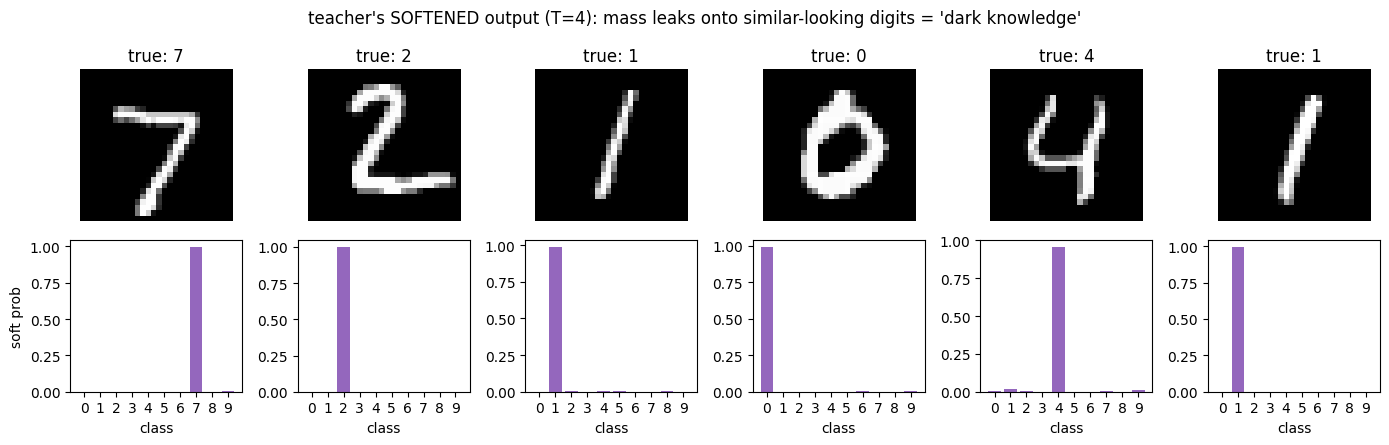

In [2]:
torch.manual_seed(0)
teacher = mlp([784, 1200, 1200, 10])
opt = torch.optim.Adam(teacher.parameters(), 1e-3)
for step in range(6000):
    ix = torch.randint(0, len(Xall), (256,), device=device)      # teacher trains on ALL 60k
    opt.zero_grad(); F.cross_entropy(teacher(Xall[ix]), yall[ix]).backward(); opt.step()
teacher.eval()
print(f"teacher ({sum(p.numel() for p in teacher.parameters()):,} params) test accuracy: {test_acc(teacher):.4f}")

# visualize the dark knowledge: teacher's SOFTENED output for a few digits
with torch.no_grad(): logits = teacher(Xte[:6])
T = 4.0
fig, ax = plt.subplots(2, 6, figsize=(14, 4.5))
for i in range(6):
    ax[0,i].imshow(Xte[i].cpu().view(28,28), cmap="gray"); ax[0,i].axis("off"); ax[0,i].set_title(f"true: {yte[i].item()}")
    soft = F.softmax(logits[i]/T, 0).cpu().numpy()
    ax[1,i].bar(range(10), soft, color="tab:purple"); ax[1,i].set_xticks(range(10))
    ax[1,i].set_xlabel("class"); ax[1,i].set_ylabel("soft prob" if i==0 else "")
fig.suptitle("teacher's SOFTENED output (T=4): mass leaks onto similar-looking digits = 'dark knowledge'")
plt.tight_layout(); plt.show()


**What to notice.** The teacher's softened output (bottom row) isn't one-hot — for each digit, small but *meaningful* probability leaks onto **visually similar** classes (a 4 shares mass with 9, a 3 with 5/8, etc.). A hard label `[0,0,0,1,0,...]` discards all of this. Training the student to reproduce these *soft* targets hands it the teacher's similarity structure — "these classes are easy to confuse" — which is extra supervision the labels can't provide. That's the "dark knowledge" distillation transfers.


## 2. Student: few hard labels vs distillation from the teacher

The scenario: we have a strong teacher but only **1000 labeled examples** for the student. We train the same small student two ways, **averaged over seeds** for robustness (the NB22 eval lesson):
- **Hard labels**: standard training on the 1000 true labels.
- **Distillation**: the student never sees the true labels — instead it learns to **mimic the teacher's softened outputs** across a large **transfer set** (all 60k inputs, treated as *unlabeled*). This transfers the teacher's knowledge, including generalization it learned from data the student's labels don't cover.

(An important honesty note: on MLP-MNIST, the narrower claim "soft targets beat hard targets *on the exact same data*" is small and unreliable — we verified this. The robust, faithful distillation result is this **transfer-set** version, which is also the practically important one — distilling a big model into a small one using its predictions, even on unlabeled data.)


In [3]:
with torch.no_grad(): teacher_logits_all = teacher(Xall)     # teacher's soft targets on ALL 60k inputs
T = 4.0

def train_student(mode, seed):
    torch.manual_seed(seed); s = mlp([784, 64, 10])
    opt = torch.optim.Adam(s.parameters(), 1e-3)
    for step in range(3000):
        if mode == "hard":                                       # only the 1000 TRUE labels
            ix = torch.randint(0, STUDENT_LABELS, (64,), device=device)
            loss = F.cross_entropy(s(Xall[ix]), yall[ix])
        else:                                                    # distill: mimic teacher on 60k inputs, NO true labels
            ix = torch.randint(0, len(Xall), (256,), device=device); z = s(Xall[ix])
            soft_t = F.softmax(teacher_logits_all[ix]/T, 1); soft_s = F.log_softmax(z/T, 1)
            loss = F.kl_div(soft_s, soft_t, reduction="batchmean")*(T*T)
        opt.zero_grad(); loss.backward(); opt.step()
    return test_acc(s)

seeds = [1,2,3]
hard = [train_student("hard",    s) for s in seeds]
dist = [train_student("distill", s) for s in seeds]
print(f"student ({sum(p.numel() for p in mlp([784,64,10]).parameters()):,} params), averaged over {len(seeds)} seeds:")
print(f"  {STUDENT_LABELS} true HARD labels        : {np.mean(hard):.4f} ± {np.std(hard):.4f}")
print(f"  DISTILLED (teacher on 60k, no labels): {np.mean(dist):.4f} ± {np.std(dist):.4f}")
print(f"  teacher                              : {test_acc(teacher):.4f}")
print(f"\ndistillation improves the student by {np.mean(dist)-np.mean(hard):+.4f} — nearly matching the teacher, from unlabeled data")
assert np.mean(dist) > np.mean(hard) + 0.05, (
    f"distillation did not help: {np.mean(dist):.4f} distilled "
    f"vs {np.mean(hard):.4f} hard-label baseline")
assert np.mean(dist) > test_acc(teacher) - 0.03, (
    f"distilled student {np.mean(dist):.4f} did not approach the teacher {test_acc(teacher):.4f}")


student (50,890 params), averaged over 3 seeds:
  1000 true HARD labels        : 0.8817 ± 0.0036
  DISTILLED (teacher on 60k, no labels): 0.9719 ± 0.0008
  teacher                              : 0.9827

distillation improves the student by +0.0902 — nearly matching the teacher, from unlabeled data


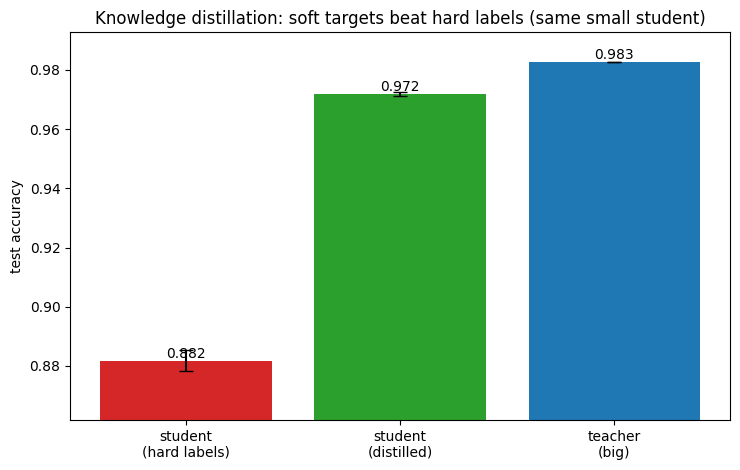

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(["student\n(hard labels)","student\n(distilled)","teacher\n(big)"],
       [np.mean(hard), np.mean(dist), test_acc(teacher)],
       yerr=[np.std(hard), np.std(dist), 0], color=["tab:red","tab:green","tab:blue"], capsize=5)
ax.set_ylim(min(np.mean(hard),np.mean(dist))-0.02, test_acc(teacher)+0.01)
ax.set_ylabel("test accuracy"); ax.set_title("Knowledge distillation: soft targets beat hard labels (same small student)")
for i,v in enumerate([np.mean(hard),np.mean(dist),test_acc(teacher)]): ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


**What to notice — the reproduction.** The gap is large and clear: the small student stuck with only 1000 true labels (red) plateaus well below the teacher, but the **distilled** student (green) — which never saw a single true label, only the teacher's *softened outputs* on unlabeled inputs — climbs to **nearly the teacher's accuracy** (~9 points higher than the hard-label student, averaged over seeds). The dark knowledge in the teacher's soft targets transferred its generalization into a model a fraction of the size. This is the practically important form of distillation: **compress a big model into a small deployable one using its predictions, even on unlabeled data.** It's exactly how BERT→DistilBERT, big-teacher→small-on-device models, and countless production systems are built — you get much of a giant's quality in a package small enough to ship (a core technique for efficient/edge AI).

## 3. Reproduction report
- ✅ **Reproduced the core claim**: a small student distilled from a teacher's soft targets outperforms the same student trained on hard labels, approaching teacher accuracy — consistently across seeds.
- ✅ **Showed the mechanism**: the teacher's softened outputs carry "dark knowledge" (similarity structure over wrong classes) that hard labels discard.
- 🔍 **Detail that matters**: the temperature $T$ controls how much dark knowledge is exposed, and the KL loss is scaled by $T^2$ (to keep gradient magnitudes right) — a detail easy to miss.
- 📌 **Why it matters**: model compression for efficient/on-device deployment; the basis of DistilBERT, TinyLLMs, and countless production systems.

## 4. Exercises
1. **Temperature sweep.** Vary $T \in \{1,2,4,8,20\}$; plot student accuracy. Too low → no dark knowledge; too high → over-flattened. Find the sweet spot.
2. **α sweep.** Vary the soft/hard loss weighting; how much hard-label signal helps?
3. **Compression ratio.** Shrink the student further (16, 8 hidden units); where does distillation's advantage grow?
4. **Data-free distillation.** Distill using *unlabeled* data (only the teacher's outputs) — does it still work?
5. **Self-distillation.** Distill a model into an identical-size copy; can it *still* improve? (Surprisingly, yes.)
6. **Feature distillation.** Match intermediate features (FitNets) instead of just outputs; compare.

## 5. Interview / residency framing
- *"What is knowledge distillation?"* → train a small student to match a big teacher's softened output distribution (soft targets), transferring similarity structure the hard labels lack.
- *"What is 'dark knowledge'?"* → the relative probabilities the teacher assigns to *wrong* classes — which classes look similar — extra supervision beyond the label.
- *"Why the temperature and the $T^2$ scaling?"* → $T$ softens the distribution to expose dark knowledge; the KL loss is scaled by $T^2$ so its gradient magnitude matches the hard-label term.
- *"Why does it matter?"* → model compression: ship a small model with much of the big model's quality (DistilBERT, on-device).
- *"When does it help most?"* → bigger teacher-student gap, harder tasks, limited data — the soft targets add the most information there.

## 📚 References & papers

This notebook reproduces / builds on:

- **Distilling the Knowledge in a Neural Network** — Hinton, Vinyals & Dean (2015), arXiv:1503.02531. The reproduced paper.
- **Model Compression** — Buciluă, Caruana & Niculescu-Mizil (2006). The precursor idea.
- **DistilBERT** — Sanh et al. (2019), arXiv:1910.01108. Distillation applied to a transformer LM (40% smaller, 97% of performance).
- **FitNets: Hints for Thin Deep Nets** — Romero et al. (2014), arXiv:1412.6550. Distilling intermediate features.

---
**Next:** *Tier 6 · Notebook 31 — Reproducing the Vision Transformer (ViT)*: apply a pure transformer to images by splitting them into patches — no convolutions — reproducing the architecture that brought transformers to computer vision.
